In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

columns = [
    "Class label", "Alcohol", "Malic acid", "Ash", "Alcalinity of ash",
    "Magnesium", "Total phenols", "Flavanoids", "Nonflavanoid phenols",
    "Proanthocyanins", "Color intensity", "Hue",
    "OD280/OD315 of diluted wines", "Proline",
]

df_wine = pd.read_csv("data/wine_data.csv", header=None)
df_wine.columns = columns
df_wine.head()


,Class label,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


# Principal Component Analysis on the Wine dataset

The goal is to standardize the features, compute principal components, project the data to two dimensions, and classify the projected data.


In [2]:
X = df_wine.iloc[:, 1:].values
y = df_wine.iloc[:, 0].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y
)

sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

print("# of data:", X.shape[0])
print("# of features:", X.shape[1])
print("Training shape:", X_train_std.shape)
print("Testing shape:", X_test_std.shape)


# of data: 178
# of features: 13
Training shape: (124, 13)
Testing shape: (54, 13)


In [3]:
cov_mat = np.cov(X_train_std.T)
eigen_vals, eigen_vecs = np.linalg.eigh(cov_mat)
order = np.argsort(eigen_vals)[::-1]
eigen_vals = eigen_vals[order]
eigen_vecs = eigen_vecs[:, order]

explained = eigen_vals / eigen_vals.sum()
eigen_summary = pd.DataFrame({
    "component": np.arange(1, len(eigen_vals) + 1),
    "eigenvalue": eigen_vals,
    "explained_variance_ratio": explained,
    "cumulative_ratio": np.cumsum(explained),
})
print("Covariance matrix shape:", cov_mat.shape)
eigen_summary


Covariance matrix shape: (13, 13)


,component,eigenvalue,explained_variance_ratio,cumulative_ratio
0,1,4.842745,0.369515,0.369515
1,2,2.416025,0.184349,0.553864
2,3,1.548458,0.118152,0.672016
3,4,0.961204,0.073343,0.745358
4,5,0.841662,0.064221,0.809579
5,6,0.662063,0.050517,0.860096
6,7,0.518285,0.039547,0.899643
7,8,0.346504,0.026439,0.926082
8,9,0.313137,0.023893,0.949975
9,10,0.213572,0.016296,0.966271


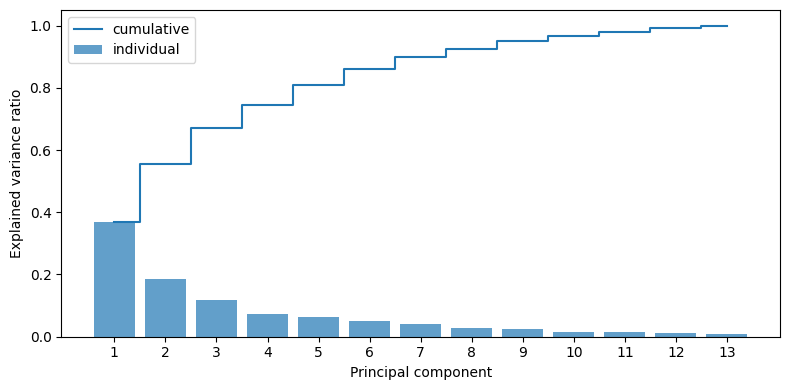

In [4]:
plt.figure(figsize=(8, 4))
plt.bar(range(1, len(explained) + 1), explained, alpha=0.7, label="individual")
plt.step(range(1, len(explained) + 1), np.cumsum(explained), where="mid", label="cumulative")
plt.ylabel("Explained variance ratio")
plt.xlabel("Principal component")
plt.xticks(range(1, len(explained) + 1))
plt.legend(loc="best")
plt.tight_layout()
plt.show()


In [5]:
w = eigen_vecs[:, :2]
X_train_pca_manual = X_train_std.dot(w)
print("Matrix W:")
print(w)
pd.DataFrame(X_train_pca_manual[:10], columns=["PC 1", "PC 2"])


Matrix W:
[[-0.13724218 -0.50303478]
 [ 0.24724326 -0.16487119]
 [-0.02545159 -0.24456476]
 [ 0.20694508  0.11352904]
 [-0.15436582 -0.28974518]
 [-0.39376952 -0.05080104]
 [-0.41735106  0.02287338]
 [ 0.30572896 -0.09048885]
 [-0.30668347 -0.00835233]
 [ 0.07554066 -0.54977581]
 [-0.32613263  0.20716433]
 [-0.36861022  0.24902536]
 [-0.29669651 -0.38022942]]


,PC 1,PC 2
0,2.382990,-0.454585
1,-1.965782,-1.653769
2,-2.539076,-1.029091
3,-1.430108,-0.602401
4,3.141472,-0.662150
5,0.502536,2.089071
6,0.048677,2.275360
7,2.478890,0.086033
8,2.019003,1.353872
9,0.751566,2.553679


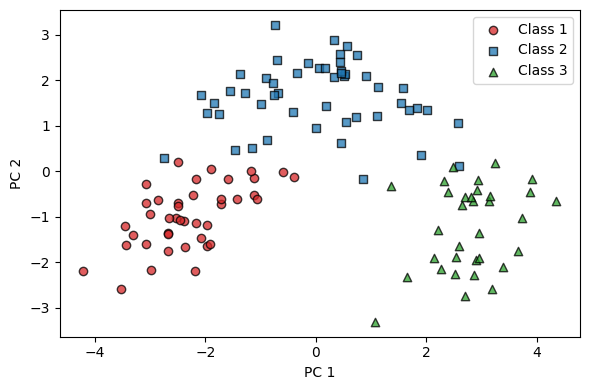

In [6]:
plt.figure(figsize=(6, 4))
for label, color, marker in zip(np.unique(y_train), ["tab:red", "tab:blue", "tab:green"], ["o", "s", "^"]):
    plt.scatter(
        X_train_pca_manual[y_train == label, 0],
        X_train_pca_manual[y_train == label, 1],
        color=color,
        marker=marker,
        edgecolor="black",
        alpha=0.75,
        label=f"Class {label}",
    )
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.legend(loc="best")
plt.tight_layout()
plt.show()


In [7]:
pca = PCA(n_components=2)
lr = LogisticRegression(max_iter=1000)

X_train_pca = pca.fit_transform(X_train_std)
X_test_pca = pca.transform(X_test_std)
lr.fit(X_train_pca, y_train)

print("sklearn PCA explained variance ratio:", pca.explained_variance_ratio_)
print("Training accuracy:", lr.score(X_train_pca, y_train))
print("Testing accuracy:", lr.score(X_test_pca, y_test))


sklearn PCA explained variance ratio: [0.36951469 0.18434927]
Training accuracy: 0.9838709677419355
Testing accuracy: 0.9259259259259259


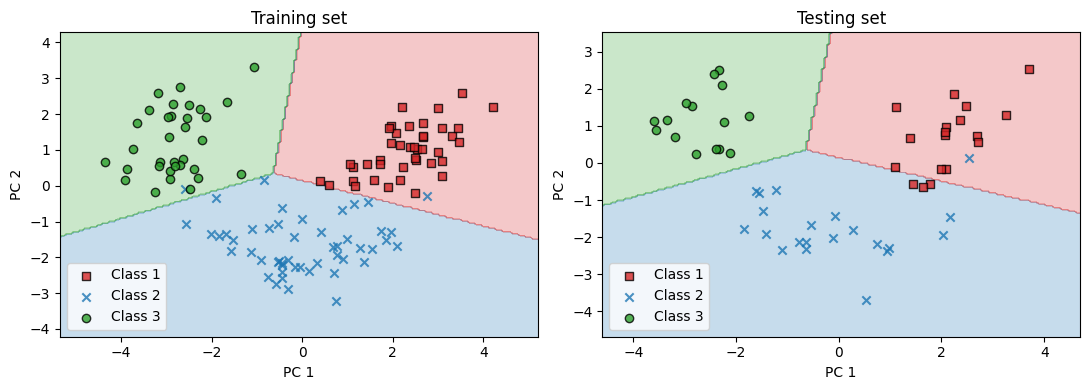

In [8]:
def plot_decision_regions(X, y, classifier, ax, resolution=0.05):
    markers = ("s", "x", "o", "^", "v")
    colors = ("tab:red", "tab:blue", "tab:green", "tab:gray", "tab:cyan")
    cmap = ListedColormap(colors[:len(np.unique(y))])

    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(
        np.arange(x1_min, x1_max, resolution),
        np.arange(x2_min, x2_max, resolution),
    )
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T).reshape(xx1.shape)
    ax.contourf(xx1, xx2, Z, alpha=0.25, cmap=cmap)
    ax.set_xlim(xx1.min(), xx1.max())
    ax.set_ylim(xx2.min(), xx2.max())

    for idx, cl in enumerate(np.unique(y)):
        ax.scatter(
            X[y == cl, 0], X[y == cl, 1],
            alpha=0.8,
            color=colors[idx],
            edgecolor="black",
            marker=markers[idx],
            label=f"Class {cl}",
        )

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_decision_regions(X_train_pca, y_train, classifier=lr, ax=axes[0])
axes[0].set_title("Training set")
axes[0].set_xlabel("PC 1")
axes[0].set_ylabel("PC 2")
axes[0].legend(loc="lower left")

plot_decision_regions(X_test_pca, y_test, classifier=lr, ax=axes[1])
axes[1].set_title("Testing set")
axes[1].set_xlabel("PC 1")
axes[1].set_ylabel("PC 2")
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()


In [9]:
loadings = pd.DataFrame({
    "feature": columns[1:],
    "PC1_loading": pca.components_[0],
    "PC2_loading": pca.components_[1],
})
loadings.reindex(loadings["PC1_loading"].abs().sort_values(ascending=False).index)


,feature,PC1_loading,PC2_loading
6,Flavanoids,0.417351,-0.022873
5,Total phenols,0.393770,0.050801
11,OD280/OD315 of diluted wines,0.368610,-0.249025
10,Hue,0.326133,-0.207164
8,Proanthocyanins,0.306683,0.008352
7,Nonflavanoid phenols,-0.305729,0.090489
12,Proline,0.296697,0.380229
1,Malic acid,-0.247243,0.164871
3,Alcalinity of ash,-0.206945,-0.113529
4,Magnesium,0.154366,0.289745
